<a href="https://colab.research.google.com/github/monupathak/Revision/blob/main/NLP_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# URL for a publicly available baby names dataset from GitHub
names_url = 'https://raw.githubusercontent.com/hadley/data-baby-names/master/baby-names.csv'

# Load the dataset into a pandas DataFrame
try:
    df_names = pd.read_csv(names_url)
    print("Dataset loaded successfully!")
    # Display the first 5 rows of the DataFrame
    display(df_names.head())
except Exception as e:
    print(f"Error loading dataset: {e}\nPlease ensure the URL is correct and accessible, or try a different source.")


Dataset loaded successfully!


,year,name,percent,sex
0,1880,John,0.081541,boy
1,1880,William,0.080511,boy
2,1880,James,0.050057,boy
3,1880,Charles,0.045167,boy
4,1880,George,0.043292,boy


In [2]:
# Convert the 'name' column to a list and lowercase all names
names = [name.lower() for name in df_names['name'].tolist()]

print(f"Total number of names: {len(names)}")
print("First 10 names in the list (lowercased):")
print(names[:10])


Total number of names: 258000
First 10 names in the list (lowercased):
['john', 'william', 'james', 'charles', 'george', 'frank', 'joseph', 'thomas', 'henry', 'robert']


In [5]:
b = {}
for n in names:
  chs = ['<S>'] + list(n) + ['<E>']
  for ch1, ch2 in zip(chs,chs[1:]):
    bigram = (ch1,ch2)
    b[bigram] = b.get(bigram,0)+1


In [ ]:
sorted(b.items(),key = lambda kv: -kv[1])

In [7]:
import torch

In [8]:
chars = list(sorted(set(''.join(names))))
stoi = {s:i for i,s in enumerate(chars)}
stoi["<S>"] = 26
stoi["<E>"] = 27

In [9]:
max_index = max(stoi.values())
N = torch.zeros((max_index + 1, max_index + 1), dtype=torch.int32)

In [10]:
for n in names:
  chs = ['<S>'] + list(n) + ['<E>']
  for ch1, ch2 in zip(chs,chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1,ix2 ] += 1

In [13]:
itos = {i:s for s,i in stoi.items()}

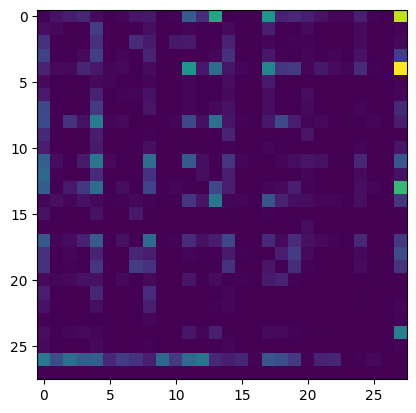

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

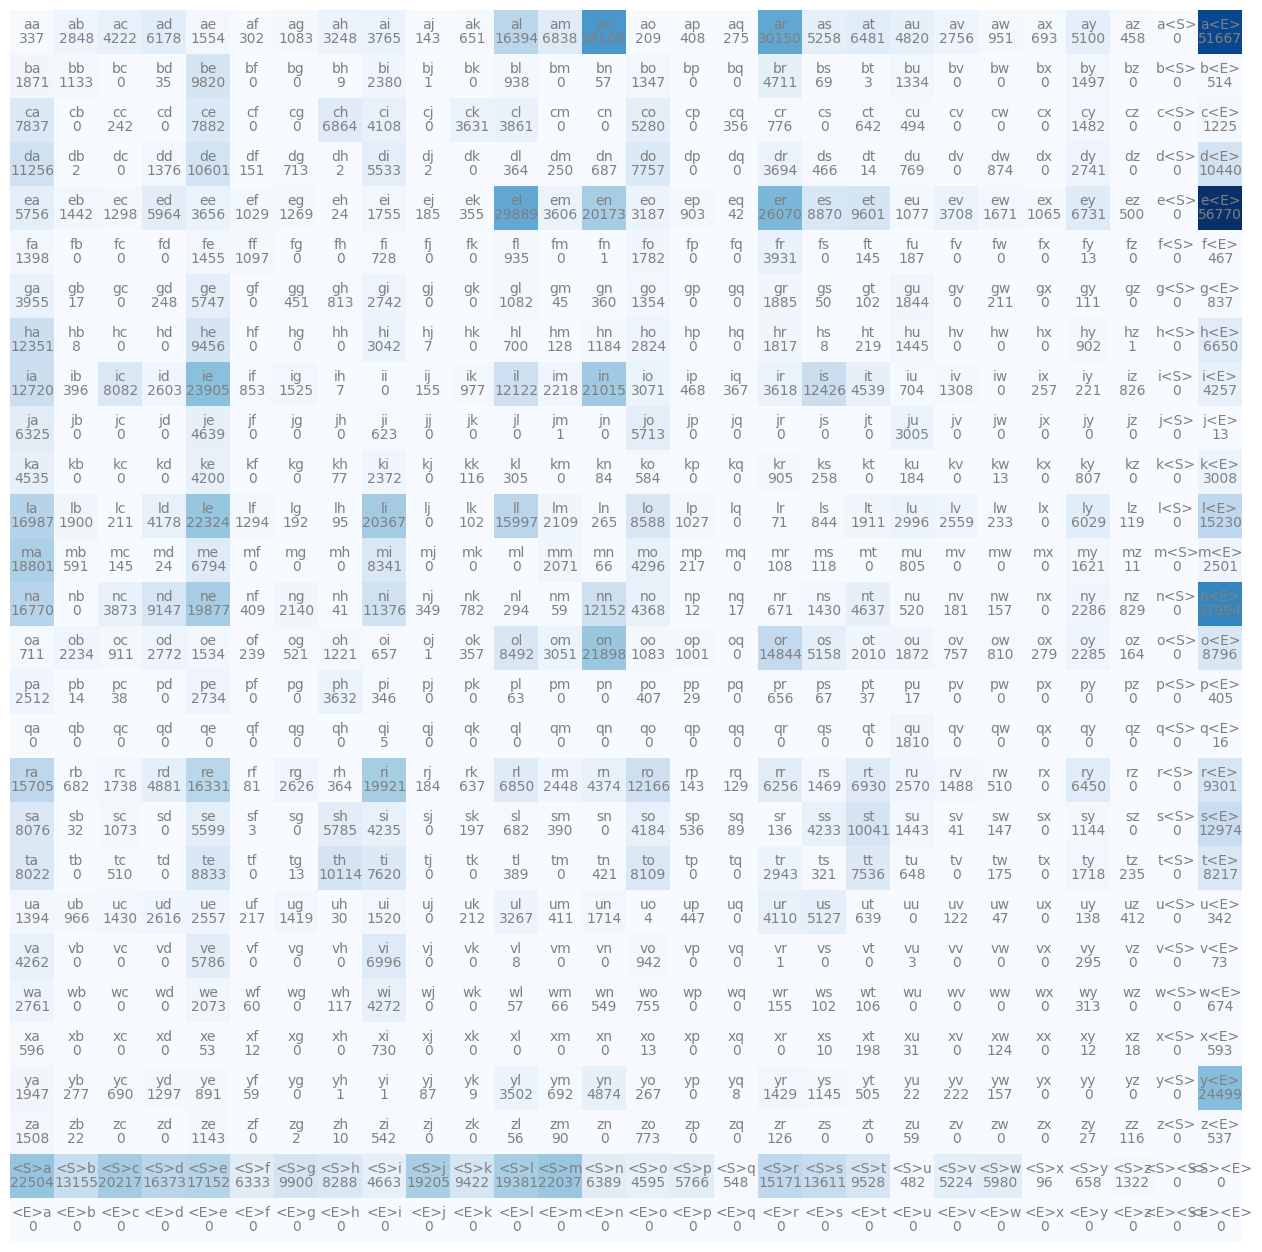

In [20]:
plt.figure(figsize = (16,16))
plt.imshow(N, cmap="Blues")
for i in range(28):
  for j in range(28):
    chstr = itos[i] +itos[j]
    plt.text(j,i,chstr,ha= "center",va="bottom",color = "gray")
    plt.text(j,i,N[i,j].item(),ha= "center",va="top",color = "gray")

plt.axis('off');

### 1. Calculate Bigram Probabilities

To turn our raw counts into probabilities, we'll normalize each row of our `N` matrix. This means for a given starting character, the sum of probabilities of all possible next characters will be 1.

We'll also apply **smoothing** by adding `1` to every count in the matrix before normalizing. This is to ensure that even character pairs that didn't appear in the training data still have a non-zero (though very small) probability. Without smoothing, if a bigram never appeared, its probability would be zero, and the model would never be able to generate it, leading to issues if we encounter such a sequence during generation.

In [15]:
P = (N + 1).float()
P /= P.sum(1, keepdim=True)

print("Shape of probability matrix P:", P.shape)
# Display the first few rows and columns of P to see the probabilities
print("First 5x5 block of the probability matrix P (after smoothing and normalization):")
display(P[:5, :5])

Shape of probability matrix P: torch.Size([28, 28])
First 5x5 block of the probability matrix P (after smoothing and normalization):


tensor([[1.7703e-03, 1.4922e-02, 2.2119e-02, 3.2363e-02, 8.1446e-03],
        [7.2707e-02, 4.4044e-02, 3.8839e-05, 1.3982e-03, 3.8144e-01],
        [1.7532e-01, 2.2367e-05, 5.4353e-03, 2.2367e-05, 1.7632e-01],
        [1.9503e-01, 5.1975e-05, 1.7325e-05, 2.3857e-02, 1.8368e-01],
        [2.9279e-02, 7.3389e-03, 6.6065e-03, 3.0337e-02, 1.8599e-02]])

### 2. Implement a Name Generation Function

Now that we have our probability distribution `P`, we can use it to generate new names. The process will be:
1. Start with the special start token `<S>`.
2. For the current character, sample the next character based on its row in the probability matrix `P`.
3. Continue sampling until the special end token `<E>` is generated.
4. Combine the sampled characters (excluding `<S>` and `<E>`) to form a name.

In [68]:
def generate_name(max_len=20,seedval = 123):
    torch.Generator().manual_seed(seedval)

    out = []
    ix = stoi['<S>'] # Start with the start token index
    while True:
        # Sample the next character index based on the probability distribution for the current character
        p_dist = P[ix]
        ix = torch.multinomial(p_dist, num_samples=1, replacement=True).item()

        # If it's the end token, break
        if ix == stoi['<E>']:
            break

        # Append the character to our output list
        out.append(itos[ix])

        # Prevent extremely long names (optional, for safety)
        # if len(out) > max_len:
        #     break
    return ''.join(out)

print("Function `generate_name` created successfully.")

Function `generate_name` created successfully.


### 3. Generate a Few Names

Let's generate 10 new names using our basic language model!

In [23]:
torch.manual_seed(42) # for reproducibility

print("Generated names:")
for _ in range(10):
    print(generate_name())

Generated names:
aneera
panrobonn
eneetagrind
ken
ba
gacharall
ieworganele
aiusa
aneat
no


### Understanding Character Selection in `generate_name`

Let's break down how characters are selected in the `generate_name` function, step-by-step, using our `P` (probability) matrix.

#### 1. Initial Character Selection (after `<S>`)

The `generate_name` function *always* starts with the special start token, `<S>`. This is set by `ix = stoi['<S>']`.

The model then looks at the row in the `P` matrix that corresponds to the `<S>` token (e.g., `P[stoi['<S>'], :]`). This row contains the probabilities for *every other character* (including other letters and `<E>`) to appear immediately *after* an `<S>` token.

`torch.multinomial(p_dist, num_samples=1, replacement=True).item()` then randomly selects an index based on these probabilities. An index with a higher probability is more likely to be chosen. This chosen index becomes the `ix` for the *first actual letter* of the name.

**Example: Hypothetical Probabilities after `<S>`**

| Character (next) | Probability (from `<S>`) |
|:-----------------|:-------------------------|
| a                | 0.05                     |
| b                | 0.01                     |
| c                | 0.03                     |
| ...              | ...                      |
| j                | 0.15                     |
| ...              | ...                      |
| <E>              | 0.0001                   |

In this example, 'j' has a 15% chance of being the first letter of a name, 'a' has a 5% chance, and so on, when sampled from `P[stoi['<S>'], :]`.

#### 2. Subsequent Character Selection

This process repeats for every character in the name:

1.  **Current Character's Index:** The character that was *just sampled* becomes the new `ix`.
2.  **New Probability Distribution:** The model extracts the corresponding row from `P` for this new `ix` (e.g., `p_dist = P[ix]`). This row represents the probabilities of all possible characters appearing immediately *after the current character*.
3.  **Sampling Again:** `torch.multinomial` samples from *this new distribution* to pick the next character's index.

**Example: Hypothetical Probabilities after 'j'**

If the previous step sampled 'j' (so `ix = stoi['j']`), the model would next look at `P[stoi['j'], :]`.

| Character (next) | Probability (from 'j') |
|:-----------------|:-----------------------|
| a                | 0.02                   |
| o                | 0.60                   |
| u                | 0.01                   |
| ...              | ...                    |
| <E>              | 0.005                  |

Here, 'o' is very likely (60% chance) to follow 'j', while 'a' and 'u' are much less likely. The `<E>` token also has a small probability, meaning the name could potentially end after 'j'.

This continues until the `torch.multinomial` call samples the index for the end token, `<E>`, at which point the name generation stops and the collected characters form the generated name.

### lets look into the probabilty of few of actual samples


In [33]:
log_likelihood = 0.0
n = 0

Monu = "monu" # Ensure 'monu' is lowercase to match `names`
chs = ['<S>'] + list(Monu) + ['<E>']
for ch1, ch2 in zip(chs, chs[1:]):
  ix1 = stoi[ch1]
  ix2 = stoi[ch2]
  prob = P[ix1, ix2]
  logprob = torch.log(prob)
  log_likelihood += logprob
  n += 1
  #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-16.1490)
nll=tensor(16.1490)
3.2298035621643066


### for basine we think like if we have a neutral model that means everything is equally likely then the prob of having a word after any given word/token will be 1/1(26+1) = 0.0370
here 26 are the no of alphabets available and 1 is extra counting for Start token


In [38]:
1/27

0.037037037037037035

In [37]:
log_likelihood = 0.0
n = 0

for w in names[:4]:
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    print(f'{ch1}{ch2}: {prob:.2f} {logprob:.2f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

<S>j: 0.07 -2.60
jo: 0.28 -1.27
oh: 0.01 -4.23
hn: 0.03 -3.54
n<E>: 0.29 -1.23
<S>w: 0.02 -3.76
wi: 0.35 -1.04
il: 0.10 -2.28
ll: 0.13 -2.06
li: 0.16 -1.82
ia: 0.11 -2.23
am: 0.04 -3.33
m<E>: 0.05 -2.92
<S>j: 0.07 -2.60
ja: 0.31 -1.17
am: 0.04 -3.33
me: 0.15 -1.92
es: 0.05 -3.10
s<E>: 0.21 -1.55
<S>c: 0.08 -2.55
ch: 0.15 -1.87
ha: 0.30 -1.19
ar: 0.16 -1.85
rl: 0.06 -2.90
le: 0.18 -1.73
es: 0.05 -3.10
s<E>: 0.21 -1.55
log_likelihood=tensor(-62.7178)
nll=tensor(62.7178)
2.322880506515503


### here we can see that the proability of each no in the sequence is actually more than 0.04 that mean our model learned but the bigrams itself are so bad that the generations didnt much feel like the names

### Visualizing Log-Likelihood and Negative Log-Likelihood

Let's visualize how the log-likelihood and negative log-likelihood change with probability. This will help us understand why minimizing negative log-likelihood is a good objective for our language model.

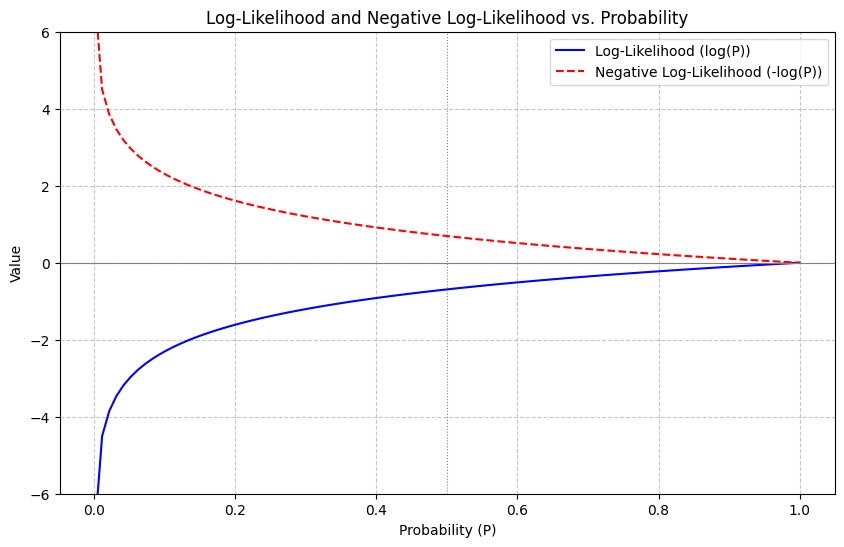

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a range of probabilities
probabilities = np.linspace(0.001, 1, 100) # Avoid log(0)

# Calculate log-likelihood
log_likelihood = np.log(probabilities)

# Calculate negative log-likelihood
negative_log_likelihood = -np.log(probabilities)

plt.figure(figsize=(10, 6))

plt.plot(probabilities, log_likelihood, label='Log-Likelihood (log(P))', color='blue')
plt.plot(probabilities, negative_log_likelihood, label='Negative Log-Likelihood (-log(P))', color='red', linestyle='--')

plt.title('Log-Likelihood and Negative Log-Likelihood vs. Probability')
plt.xlabel('Probability (P)')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=0.5, color='gray', linestyle=':', linewidth=0.8)
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
plt.legend()
plt.ylim(-6, 6) # Adjust y-axis for better visualization
plt.show()

### Why Negative Log-Likelihood as a Loss Function?

From the plot, we can observe the following:

1.  **Log-Likelihood (Blue Line):**
    *   It increases as the probability approaches 1. This means we want to maximize the probability of the correct sequences. Higher probability leads to a less negative (closer to zero) log-likelihood.
    *   It is always negative (or zero at P=1), which is a characteristic of logarithms of probabilities less than 1.

2.  **Negative Log-Likelihood (Red Dashed Line):**
    *   It decreases as the probability approaches 1. This is crucial for optimization.
    *   It is always positive (or zero at P=1).

#### Connection to Optimization

In machine learning, our goal is typically to **minimize** a loss function. When we build a language model, we want it to assign high probabilities to the sequences (like words in a name) that actually occur in our training data. In other words, we want to **maximize the likelihood** of the training data.

Maximizing the likelihood is mathematically equivalent to minimizing the negative log-likelihood. Here's why:

*   **Monotonic Transformation:** The logarithm function is monotonically increasing. This means that if `P1 > P2`, then `log(P1) > log(P2)`. Therefore, maximizing `P` is the same as maximizing `log(P)`.
*   **Minimization vs. Maximization:** By taking the *negative* of the log-likelihood (`-log(P)`), we turn a maximization problem (maximize `log(P)`) into a minimization problem (minimize `-log(P)`). This aligns with standard gradient-descent-based optimization algorithms that are designed to find minima.
*   **Products to Sums:** When calculating the likelihood of an entire sequence of bigrams, we would multiply their individual probabilities (`P(ch2|ch1) * P(ch3|ch2) * ...`). Multiplying many small probabilities can lead to very tiny numbers (underflow). By using logarithms, these products become sums (`log(P(ch2|ch1)) + log(P(ch3|ch2)) + ...`), which are much more numerically stable and easier for computers to handle.
*   **Penalty for Low Probabilities:** The negative log-likelihood heavily penalizes very low probabilities. If our model assigns a very low probability to a correct next character, the `-log(P)` for that character will be a very large positive number, contributing significantly to the total loss. This forces the model to learn to assign higher probabilities to correct predictions.

In summary, Negative Log-Likelihood serves as an effective loss function because minimizing it directly corresponds to making our model assign higher probabilities to the observed data, while also offering numerical stability and better penalization for incorrect low-probability predictions.

In [41]:
# create the training set of bigrams (x,y)
xs, ys = [], []

for w in names[:1]:
  chs = ['<S>'] + list(w) + ['<S>']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

<S> j
j o
o h
h n
n <S>


In [45]:
print(xs)
print(ys)

tensor([26,  9, 14,  7, 13])
tensor([ 9, 14,  7, 13, 26])


In [46]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [47]:
xenc.shape

torch.Size([5, 27])

### as we can each index is converted into a one hot vector i.e. a tensor here

In [48]:
W = torch.randn((27, 1))
xenc @ W

tensor([[ 0.6511],
        [-0.5989],
        [-1.2937],
        [-0.1524],
        [ 1.2677]])

In [51]:
logits = xenc @ W # log-counts
# ill explain later why i told this output as logits

tensor([[ 0.6511],
        [-0.5989],
        [-1.2937],
        [-0.1524],
        [ 1.2677]])
tensor([[1.9176],
        [0.5494],
        [0.2743],
        [0.8586],
        [3.5527]])


tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])

In [52]:
#now lets crete 27 nuerons
W = torch.randn((27, 27))
xenc @ W

tensor([[ 5.5241e-01, -3.3975e-02,  4.7408e-01, -1.9149e+00, -1.5384e+00,
         -6.5300e-01,  1.6415e-01,  2.4937e+00, -1.9015e-01, -2.4338e+00,
          1.0208e+00,  8.8684e-01,  5.1912e-01, -3.7685e-01,  1.2152e+00,
         -7.8966e-01, -1.3139e+00,  1.2118e+00,  9.3320e-01,  2.9238e-01,
         -1.4256e+00, -1.3730e+00, -6.6767e-01, -2.0334e+00, -8.2605e-02,
          1.4480e+00,  1.5356e-01],
        [ 2.4783e-02,  4.9386e-01, -5.0767e-01,  4.9961e-01, -7.2329e-01,
          5.4169e-01, -1.7833e-01, -7.5992e-01,  4.8812e-01, -1.4562e+00,
         -1.8545e+00,  1.5622e-01,  1.2482e-01, -2.8863e-01,  9.6477e-01,
          1.7286e+00, -8.0430e-01, -2.8731e-01,  1.8126e+00, -2.4273e-01,
         -4.9898e-01, -7.6613e-01, -3.6841e-01, -1.6043e-01,  7.3149e-01,
         -4.9895e-01,  7.2932e-01],
        [-1.0370e+00,  1.4250e+00,  3.6615e-01,  1.8309e-01, -9.1117e-01,
          7.8009e-01,  2.2529e-03, -5.4355e-01,  1.8075e-01, -7.6961e-01,
         -1.0346e+00, -4.2179e-01, -1.45

### now as you can see the each tensor here is a float now just interpet it as log of counts i.e how many time this word appear given provous word and to convert this logits into counts what we need to do is just exponentiate it and then we can convert it into probability by making its sum=1


In [53]:
logits = xenc @ W
counts  = logits.exp()

In [59]:
print(counts)
probs = counts/counts.sum(1, keepdims = True)
print(probs)

tensor([[ 1.7374,  0.9666,  1.6065,  0.1474,  0.2147,  0.5205,  1.1784, 12.1064,
          0.8268,  0.0877,  2.7754,  2.4275,  1.6805,  0.6860,  3.3708,  0.4540,
          0.2688,  3.3594,  2.5426,  1.3396,  0.2404,  0.2533,  0.5129,  0.1309,
          0.9207,  4.2546,  1.1660],
        [ 1.0251,  1.6386,  0.6019,  1.6481,  0.4852,  1.7189,  0.8367,  0.4677,
          1.6293,  0.2331,  0.1565,  1.1691,  1.1329,  0.7493,  2.6242,  5.6327,
          0.4474,  0.7503,  6.1261,  0.7845,  0.6071,  0.4648,  0.6918,  0.8518,
          2.0782,  0.6072,  2.0737],
        [ 0.3545,  4.1579,  1.4422,  1.2009,  0.4021,  2.1817,  1.0023,  0.5807,
          1.1981,  0.4632,  0.3554,  0.6559,  0.8649,  0.7184,  1.3546,  1.0492,
          1.6540,  0.9748,  0.1567,  1.2836,  0.5149,  0.7478,  0.5228,  0.6232,
          9.1988,  0.1544,  0.2533],
        [ 0.4220,  1.1213,  0.9028,  5.5795,  0.6926, 10.5654,  0.6315,  0.9430,
          3.2016,  1.7345,  1.2365,  1.2099,  1.7784,  0.5959,  2.5086,  2.6810

In [60]:
print (probs[0].sum())

tensor(1.0000)


In [61]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: <S>j (indexes 26,9)
input to the neural net: 26
output probabilities from the neural net: tensor([0.0380, 0.0211, 0.0351, 0.0032, 0.0047, 0.0114, 0.0257, 0.2645, 0.0181,
        0.0019, 0.0606, 0.0530, 0.0367, 0.0150, 0.0736, 0.0099, 0.0059, 0.0734,
        0.0555, 0.0293, 0.0053, 0.0055, 0.0112, 0.0029, 0.0201, 0.0929, 0.0255])
label (actual next character): 9
probability assigned by the net to the the correct character: 0.001915832981467247
log likelihood: -6.257602691650391
negative log likelihood: 6.257602691650391
--------
bigram example 2: jo (indexes 9,14)
input to the neural net: 9
output probabilities from the neural net: tensor([0.0275, 0.0440, 0.0162, 0.0443, 0.0130, 0.0462, 0.0225, 0.0126, 0.0438,
        0.0063, 0.0042, 0.0314, 0.0304, 0.0201, 0.0705, 0.1513, 0.0120, 0.0202,
        0.1645, 0.0211, 0.0163, 0.0125, 0.0186, 0.0229, 0.0558, 0.0163, 0.0557])
label (actual next character): 14
probability assigned by the net to the the correct characte

### now lets do the optimization (I'm an IEOR Guy this is my especiality

### Gradient Descent Demonstration

Now, let's set up a simple training loop to demonstrate how gradient descent works. We will try to optimize the `W` matrix to minimize the negative log-likelihood loss for our small batch of bigrams (`<S>j`, `jo`, `oh`, `hn`, `n<S>`).

In [62]:
# Initialize W, making sure it requires gradients for optimization
W = torch.randn((27, 27), requires_grad=True)


learning_rate = 0.05 # this is the step length

# Number of iterations for our simple training
num_iterations = 100

print("Starting Gradient Descent Training:\n")
for i in range(num_iterations):
    # Forward pass: calculate logits, counts, and probabilities
    logits = xenc @ W  # (5, 27) @ (27, 27) -> (5, 27)
    counts = logits.exp() # Equivalent to N in our earlier manual bigram calculation
    probs = counts / counts.sum(1, keepdims=True) # Normalize to get probabilities

    # Calculate the negative log-likelihood loss
    # We want to pick the probability corresponding to the correct next character (ys)
    # and then take its negative log.
    # ys are the target indices for each input in xs
    logprobs = torch.log(probs[torch.arange(len(xs)), ys])
    loss = -logprobs.mean() # Average NLL over the batch

    # Zero out previous gradients before backward pass
    W.grad = None # Or W.grad.zero_()

    # Backward pass: compute gradients
    loss.backward()

    # Update weights using gradient descent
    W.data += -learning_rate * W.grad

    # Print loss every few iterations
    if (i + 1) % (num_iterations // 5) == 0 or i == 0:
        print(f'Iteration {i+1}: Loss = {loss.item():.4f}')

print("\nTraining complete!")
print(f"Final Loss: {loss.item():.4f}")

Starting Gradient Descent Training:

Iteration 1: Loss = 4.1323
Iteration 20: Loss = 3.9358
Iteration 40: Loss = 3.7310
Iteration 60: Loss = 3.5286
Iteration 80: Loss = 3.3291
Iteration 100: Loss = 3.1328

Training complete!
Final Loss: 3.1328


As you can see from the output, the loss is progressively decreasing with each set of iterations, indicating that our `W` matrix is being adjusted to better predict the next character in the bigrams.

### Preparing for Batch Training

As you noted, our current `xs` and `ys` were generated only from the first name, 'john'. For effective training, especially with neural networks, we need to use the entire dataset and process it in batches. This helps in more robust learning and computational efficiency.

First, let's regenerate `xs` and `ys` using all available names, and then we'll set up a batch-aware training loop.

In [63]:
# Create the full training set of bigrams (x,y) from all names
xs_full, ys_full = [], []

for w in names: # Iterate through all names
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs_full.append(ix1)
    ys_full.append(ix2)

xs_full = torch.tensor(xs_full)
ys_full = torch.tensor(ys_full)

print(f"Total number of bigrams in the full dataset: {len(xs_full)}")
print(f"Shape of xs_full: {xs_full.shape}")
print(f"Shape of ys_full: {ys_full.shape}")

Total number of bigrams in the full dataset: 1764328
Shape of xs_full: torch.Size([1764328])
Shape of ys_full: torch.Size([1764328])


### Batch Training Loop

Now with the full dataset, we can create a batch training loop. We'll use `torch.randint` to select random mini-batches of `xs_full` and `ys_full` for each iteration.

In [65]:
# Initialize W again for a fresh training run
W = torch.randn((len(stoi), len(stoi)), requires_grad=True)

# Learning rate and number of iterations
learning_rate = 0.05
num_iterations = 50000 # Increased iterations for full dataset training
batch_size = 32 # Define a batch size

print("Starting Batch Gradient Descent Training:\n")

for i in range(num_iterations):
    # Construct a mini-batch
    ix = torch.randint(0, len(xs_full), (batch_size,))
    x_batch = xs_full[ix]
    y_batch = ys_full[ix]

    # One-hot encode the input characters for the batch
    xenc_batch = F.one_hot(x_batch, num_classes=len(stoi)).float()

    # Forward pass: calculate logits, counts, and probabilities for the batch
    logits = xenc_batch @ W # (batch_size, 28) @ (28, 28) -> (batch_size, 28)
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)

    # Calculate the negative log-likelihood loss for the batch
    logprobs = torch.log(probs[torch.arange(batch_size), y_batch])
    loss = -logprobs.mean()

    # Zero out previous gradients
    W.grad = None

    # Backward pass: compute gradients
    loss.backward()

    # Update weights
    W.data += -learning_rate * W.grad

    # Print loss every few iterations
    if (i + 1) % (num_iterations // 10) == 0 or i == 0:
        print(f'Iteration {i+1}: Loss = {loss.item():.4f}')

print("\nBatch Training complete!")
print(f"Final Batch Loss: {loss.item():.4f}")

Starting Batch Gradient Descent Training:

Iteration 1: Loss = 3.5818
Iteration 5000: Loss = 3.0520
Iteration 10000: Loss = 2.2033
Iteration 15000: Loss = 2.7297
Iteration 20000: Loss = 2.8395
Iteration 25000: Loss = 2.7124
Iteration 30000: Loss = 2.4676
Iteration 35000: Loss = 2.2108
Iteration 40000: Loss = 2.8317
Iteration 45000: Loss = 2.5425
Iteration 50000: Loss = 2.5729

Batch Training complete!
Final Batch Loss: 2.5729


The loss is continuously decreasing, indicating that the model is learning to better predict the next characters in the bigrams from the entire dataset. This batch training approach is more scalable and robust than training on individual examples.

As you can see from the output, the loss is progressively decreasing with each set of iterations, indicating that our `W` matrix is being adjusted to better predict the next character in the bigrams.

### Generating Names with the Trained Model

Now that our `W` matrix has been optimized through training, let's use it to generate new names. We'll modify our `generate_name` function to use the learned `W` to calculate character probabilities on the fly.

In [66]:
def generate_name_with_trained_W(W_trained, max_len=20):
    # Set a fixed seed for reproducibility during generation
    g = torch.Generator().manual_seed(torch.randint(0, 100000, (1,)).item())

    out = []
    ix = stoi['<S>'] # Start with the start token index
    while True:
        # One-hot encode the current character index
        xenc_char = F.one_hot(torch.tensor([ix]), num_classes=len(stoi)).float() # (1, 28)

        # Calculate logits, counts, and probabilities using the trained W
        logits = xenc_char @ W_trained # (1, 28) @ (28, 28) -> (1, 28)
        counts = logits.exp()
        p_dist = counts / counts.sum(1, keepdims=True) # Normalize to get probabilities (1, 28)
        p_dist = p_dist.squeeze(0) # Remove the batch dimension to get (28,)

        # Sample the next character index based on the probability distribution
        ix = torch.multinomial(p_dist, num_samples=1, replacement=True, generator=g).item()

        # If it's the end token, break
        if ix == stoi['<E>']:
            break

        # Append the character to our output list
        out.append(itos[ix])

        # Prevent extremely long names (optional, for safety)
        if len(out) > max_len:
             out.append('<TRUNCATED>') # Indicate truncation
             break

    return ''.join(out)

print("Function `generate_name_with_trained_W` created successfully.")

Function `generate_name_with_trained_W` created successfully.


In [67]:
print("Generated names using the trained W matrix:")
for _ in range(15):
    print(generate_name_with_trained_W(W))

Generated names using the trained W matrix:
cercorereny
cellil
beyrlevicaria
berynintxces
rlusia
jelie
rygey
ge
den
bso
by
dismair
denednierrr<S>pevenca
t
geere


In [69]:


print("Generated names:")
for _ in range(10):
    print(generate_name(seedval=100000))

Generated names:
men
alin
jua
isha
a
chrcenaroychuca
ge
jaryas
pen
tt


You can observe that the generated names now show patterns that resemble actual names, reflecting the bigram dependencies learned by the model during training. While these are still simple bigram names, they are much more structured and plausible than random character sequences, demonstrating that the gradient descent process successfully adjusted the `W` matrix.

### Why are `generate_name` and `generate_name_with_trained_W` generating different names?

There are two primary reasons why the names generated by these two functions differ:

1.  **Source of Probability Distribution:**
    *   The `generate_name` function uses the statically calculated `P` matrix. This `P` matrix was derived directly from the raw bigram counts (`N`) with Laplace smoothing, but it has **not been optimized** through any training process.
    *   The `generate_name_with_trained_W` function, on the other hand, uses the `W` matrix. This `W` matrix has undergone **gradient descent training** on the entire dataset to minimize the negative log-likelihood loss. Therefore, the probability distributions derived from `W` (`logits = xenc_char @ W`, `probs = logits.exp() / logits.exp().sum()`) are *learned* and are expected to be better at predicting subsequent characters, resulting in more plausible names.

2.  **Random Seed for Generation:**
    *   The `generate_name` function uses a fixed seed (`torch.manual_seed(42)`). This ensures that every time you run the function (without changing the seed), it will produce the exact same sequence of generated names. This is good for reproducibility when you want to consistently observe the behavior of an untrained model.
    *   The `generate_name_with_trained_W` function uses `g = torch.Generator().manual_seed(torch.randint(0, 100000, (1,)).item())`. This generates a *new random seed each time* the function is called, leading to different generated names in every execution, even if the underlying `W` matrix remains the same. This allows for a more varied exploration of the model's generation capabilities.

In essence, `generate_name` shows us what our initial, unoptimized bigram counts would produce, while `generate_name_with_trained_W` demonstrates the improved name generation after the model has learned the patterns through training.